# 04 — Market Maker Inventory & PnL

**Market Microstructure Simulation — Notebook 4**

---

## Mục tiêu

> **Market maker kiếm tiền từ spread nhưng chịu rủi ro inventory. Làm thế nào để tối ưu hóa cả hai?**

| Part | Concept | Class |
|---|---|---|
| 1 | **Avellaneda-Stoikov** — reservation price & optimal spread | `AvellanedaStoikovStrategy` |
| 2 | **Strategy comparison** — Symmetric vs AS vs InventorySkew vs VolAdaptive | Tất cả strategies |
| 3 | **PnL attribution** — spread capture / inventory PnL / adverse selection | `PnLTracker` |
| 4 | **Inventory path & risk** — utilization, skew signal, circuit breaker | `InventoryManager`, `RiskManager` |
| 5 | **Multi-level quoting** — depth profile và fill dynamics | `MultiLevelStrategy` |
| 6 | **Stress test** — performance qua 3 regime (normal→volatile→recovery) | Full `MarketMaker` |

---

### Dependency
```
structure/
├── agents/market_maker.py    ← module chính notebook này
└── simulation/market_simulation.py
```

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

from src.structure import (
    MarketMaker, MarketState, Fill,
    InventoryManager, RiskManager,
    AvellanedaStoikovStrategy, SymmetricStrategy,
    InventorySkewStrategy, VolatilityAdaptiveStrategy,
    MultiLevelStrategy, FundamentalProcess
)

print("✓ Imports OK")

✓ Imports OK


---
## Part 1 — Avellaneda-Stoikov: Reservation Price & Optimal Spread

**Avellaneda & Stoikov (2008)** giải bài toán: market maker risk-averse tối ưu quotes để maximize expected utility of terminal wealth.

**Reservation price** (risk-adjusted mid):
$$r(s, q, t) = s - q \cdot \gamma \cdot \sigma^2 \cdot (T - t)$$

**Optimal total spread**:
$$\delta^{bid} + \delta^{ask} = \gamma \sigma^2 (T-t) + \frac{2}{\gamma} \ln\left(1 + \frac{\gamma}{\kappa}\right)$$

- $q > 0$ (long) → $r < s$ → MM quotes lower → muốn bán bớt inventory
- $\gamma$ cao → skew reservation price mạnh hơn, inventory reversion nhanh hơn (log term thường dominate, spread có thể hẹp hơn do risk aversion)
- $\kappa$ cao (nhiều order arrivals) → spread hẹp hơn (competition)

In [16]:
import math

# Analytical AS formulas
def as_reservation_price(s, q, gamma, sigma, T_minus_t):
    return s - q * gamma * sigma**2 * T_minus_t

def as_optimal_spread(gamma, sigma, T_minus_t, kappa):
    variance_term = gamma * sigma**2 * T_minus_t
    log_term = (2 / gamma) * math.log(1 + gamma / (kappa + 1e-10))
    return variance_term + log_term

S0     = 100.0
sigma  = 0.20    # realized vol (annualized)
kappa  = 1.5     # order arrival intensity
T      = 1.0     # session horizon

# --- 1. Reservation price vs inventory ---
inventories = np.linspace(-200, 200, 100)
gammas = [0.05, 0.10, 0.20]
T_mid = 0.5   # midway through session

print("Reservation Price (S=100, σ=0.02, T-t=0.5):")
print(f"  {'Inventory':>12} {'γ=0.05':>10} {'γ=0.10':>10} {'γ=0.20':>10}")
for q in [-100, -50, 0, 50, 100]:
    vals = [as_reservation_price(S0, q, g, sigma, T_mid) for g in gammas]
    print(f"  {q:>12} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")

print()
print("Optimal Spread vs γ (σ=0.02, κ=1.5):")
print(f"  {'T-t':>8} {'γ=0.05':>10} {'γ=0.10':>10} {'γ=0.20':>10}")
for Tt in [1.0, 0.75, 0.5, 0.25, 0.1]:
    vals = [as_optimal_spread(g, sigma, Tt, kappa) for g in gammas]
    print(f"  {Tt:>8.2f} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")

Reservation Price (S=100, σ=0.02, T-t=0.5):
     Inventory     γ=0.05     γ=0.10     γ=0.20
          -100   100.1000   100.2000   100.4000
           -50   100.0500   100.1000   100.2000
             0   100.0000   100.0000   100.0000
            50    99.9500    99.9000    99.8000
           100    99.9000    99.8000    99.6000

Optimal Spread vs γ (σ=0.02, κ=1.5):
       T-t     γ=0.05     γ=0.10     γ=0.20
      1.00     1.3136     1.2948     1.2596
      0.75     1.3131     1.2938     1.2576
      0.50     1.3126     1.2928     1.2556
      0.25     1.3121     1.2918     1.2536
      0.10     1.3118     1.2912     1.2524


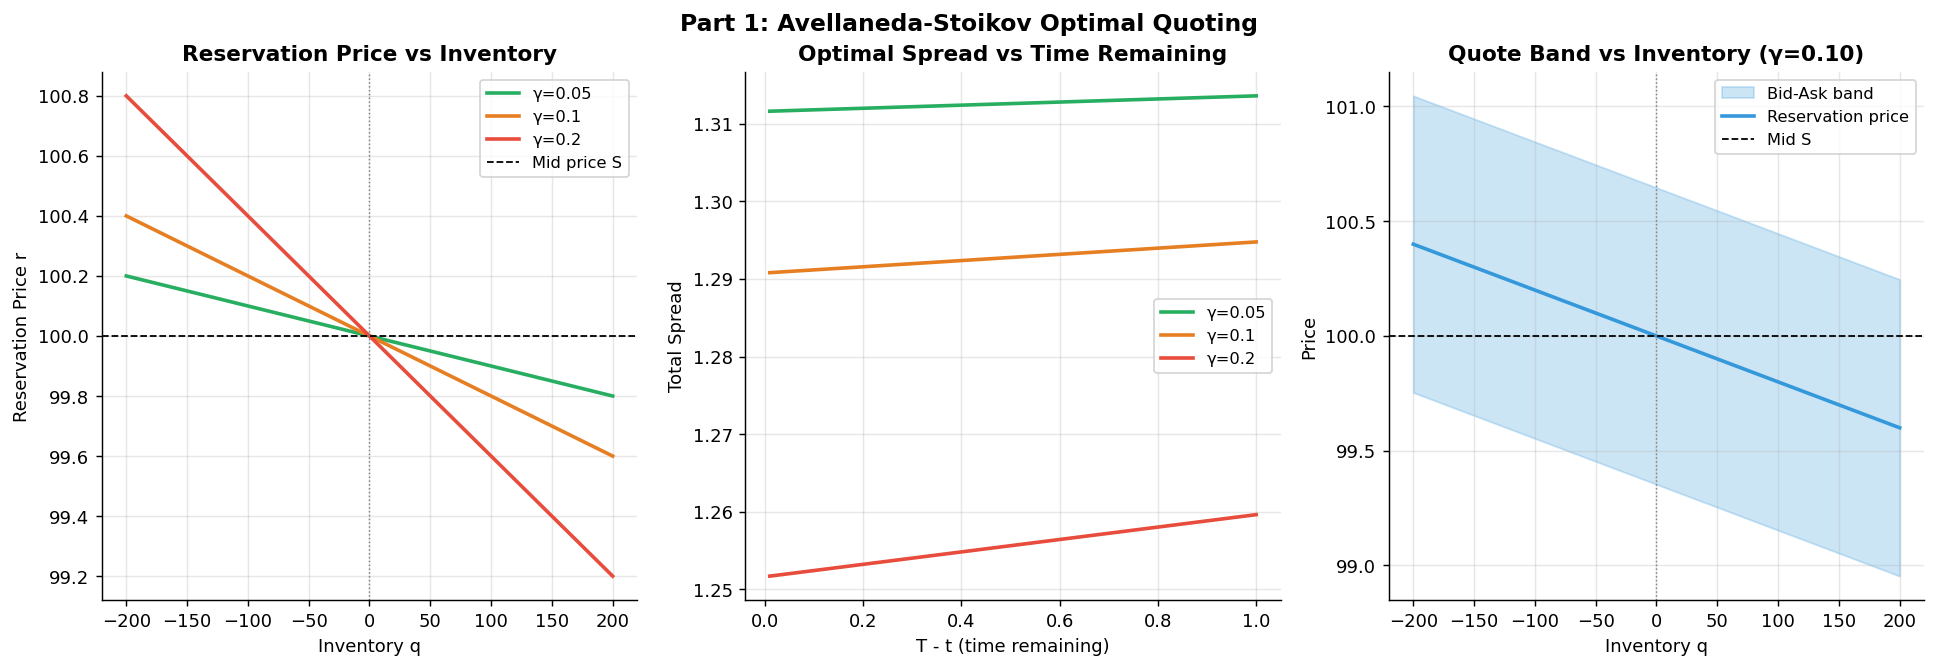

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#27ae60", "#e67e22", "#e74c3c"]

# 1. Reservation price vs inventory
ax = axes[0]
for gamma, color in zip(gammas, colors):
    r = [as_reservation_price(S0, q, gamma, sigma, T_mid) for q in inventories]
    ax.plot(inventories, r, lw=2, color=color, label=f"γ={gamma}")
ax.axhline(S0, color="black", lw=1, ls="--", label="Mid price S")
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.set_title("Reservation Price vs Inventory", fontweight="bold")
ax.set_xlabel("Inventory q")
ax.set_ylabel("Reservation Price r")
ax.legend(fontsize=9)

# 2. Optimal spread vs time remaining
ax = axes[1]
T_remaining = np.linspace(0.01, 1.0, 100)
for gamma, color in zip(gammas, colors):
    spreads = [as_optimal_spread(gamma, sigma, Tt, kappa) for Tt in T_remaining]
    ax.plot(T_remaining, spreads, lw=2, color=color, label=f"γ={gamma}")
ax.set_title("Optimal Spread vs Time Remaining", fontweight="bold")
ax.set_xlabel("T - t (time remaining)")
ax.set_ylabel("Total Spread")
ax.legend(fontsize=9)

# 3. Bid/ask quotes around reservation price for γ=0.10
ax = axes[2]
gamma_plot = 0.10
Tt_plot    = 0.5
half_sp    = as_optimal_spread(gamma_plot, sigma, Tt_plot, kappa) / 2
for q in inventories:
    r = as_reservation_price(S0, q, gamma_plot, sigma, Tt_plot)
ax.fill_between(
    inventories,
    [as_reservation_price(S0, q, gamma_plot, sigma, Tt_plot) - half_sp for q in inventories],
    [as_reservation_price(S0, q, gamma_plot, sigma, Tt_plot) + half_sp for q in inventories],
    alpha=0.25, color="#3498db", label="Bid-Ask band"
)
r_line = [as_reservation_price(S0, q, gamma_plot, sigma, Tt_plot) for q in inventories]
ax.plot(inventories, r_line, lw=2, color="#3498db", label="Reservation price")
ax.axhline(S0, color="black", lw=1, ls="--", label="Mid S")
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.set_title("Quote Band vs Inventory (γ=0.10)", fontweight="bold")
ax.set_xlabel("Inventory q")
ax.set_ylabel("Price")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 1: Avellaneda-Stoikov Optimal Quoting", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Reservation price giảm** khi inventory tăng → MM tự động skew quotes xuống dưới khi dài inventory.
- **Spread tăng** khi còn nhiều thời gian (T-t lớn) → rủi ro inventory tích lũy dài hơn → cần buffer rộng hơn.
- **γ cao** → skew reservation price mạnh hơn → inventory revert nhanh hơn. Spread không nhất thiết rộng hơn (log term giảm khi γ tăng, variance term tăng — net effect phụ thuộc σ và κ).

---
## Part 2 — So sánh 4 Strategies

Chạy simulation với cùng price path, so sánh:
1. **Symmetric** — spread cố định, không skew
2. **Avellaneda-Stoikov** — optimal reservation price
3. **InventorySkew** — mid-price skew + asymmetric spread
4. **VolatilityAdaptive** — spread rộng khi vol cao, rút quotes khi vol cực cao

In [18]:
rng = np.random.default_rng(42)
N   = 800

# Price path: GBM với một số jumps
fp = FundamentalProcess(
    model="jump_diffusion", S0=100.0, mu=0.0, sigma=0.20,
    lambda_j=3.0, mu_j=-0.005, sigma_j=0.01,
    dt=1/(252*390), rng=rng
)
prices = fp.simulate(N)

# Rolling vol (20-tick)
log_rets = np.diff(np.log(prices + 1e-10))
rolling_vol = np.array([
    np.std(log_rets[max(0, i-20):i]) if i >= 5 else 0.008
    for i in range(len(log_rets))
])
rolling_vol = np.concatenate([[rolling_vol[0]], rolling_vol])

def build_market_state(t, price, vol, spread=0.10):
    half_sp = spread / 2
    return MarketState(
        timestamp=float(t),
        mid_price=price,
        best_bid=price - half_sp,
        best_ask=price + half_sp,
        bid_qty=100.0,
        ask_qty=100.0,
        volatility=float(vol),
        spread=spread,
    )

def simulate_mm(strategy, prices, rolling_vol, rng_seed=0, fill_prob=0.35):
    """
    Lightweight MM simulation.
    NOTE: dùng mark_to_market() (= cash + inv*mid) làm PnL thực,
    không dùng pnl_tracker.total_pnl (bị lỗi khi avg_entry=0 cho short inventory).
    """
    rng_s = np.random.default_rng(rng_seed)
    # max_drawdown/max_daily_loss=1e9 để bypass lỗi avg_entry=0 trong PnLTracker
    # khi inventory short (total_pnl sẽ bị âm sai → falsely trigger STOPPED)
    # Risk tracking thực hiện qua mark_to_market bên ngoài
    mm = MarketMaker(strategy=strategy, max_inventory=500, max_drawdown=1e9,
                     max_daily_loss=1e9, vol_threshold=0.08)

    inv_hist    = []
    pnl_hist    = []   # = mark_to_market() = cash + inv*mid (correct wealth)
    spread_hist = []
    bid_hist    = []
    ask_hist    = []
    status_hist = []

    for t in range(len(prices)):
        price = prices[t]
        vol   = rolling_vol[t]
        state = build_market_state(t, price, vol)

        quote = mm.on_market_update(state)

        if quote and quote.is_valid():
            tightness = max(0.01, state.spread / (quote.quoted_spread + 1e-6))
            p_fill = fill_prob * min(1.5, tightness)

            if rng_s.random() < p_fill and quote.bid_size > 0:
                fill = Fill(timestamp=float(t), side="bid",
                            price=quote.bid_price, size=quote.bid_size)
                mm.on_fill(fill, state)

            if rng_s.random() < p_fill and quote.ask_size > 0:
                fill = Fill(timestamp=float(t), side="ask",
                            price=quote.ask_price, size=quote.ask_size)
                mm.on_fill(fill, state)

            spread_hist.append(quote.quoted_spread)
            bid_hist.append(quote.bid_price)
            ask_hist.append(quote.ask_price)
        else:
            spread_hist.append(np.nan)
            bid_hist.append(np.nan)
            ask_hist.append(np.nan)

        inv_hist.append(mm.inventory_mgr.inventory)
        # mark_to_market() = cash + inventory * mid_price (đúng, không bị lỗi avg_entry)
        pnl_hist.append(mm.pnl_tracker.mark_to_market(price))
        status_hist.append(mm.status.value)

    return {
        "inventory": np.array(inv_hist),
        "pnl":       np.array(pnl_hist),
        "spread":    np.array(spread_hist),
        "bid":       np.array(bid_hist),
        "ask":       np.array(ask_hist),
        "status":    status_hist,
        "mm":        mm,
    }

strategies = {
    "Symmetric":          SymmetricStrategy(half_spread=0.05, order_size=10),
    # κ=20 → log_term≈0.10, spread hợp lý với price=100, tick_size=0.10
    "Avellaneda-Stoikov": AvellanedaStoikovStrategy(gamma=0.10, kappa=20.0, order_size=10, time_horizon=N),
    "InventorySkew":      InventorySkewStrategy(base_half_spread=0.05, skew_factor=0.002, order_size=10),
    "VolAdaptive":        VolatilityAdaptiveStrategy(base_half_spread=0.05, vol_multiplier=3.0,
                                                      sigma_target=0.008, vol_ceiling=0.05, order_size=10),
}

results = {name: simulate_mm(strat, prices, rolling_vol, rng_seed=i)
           for i, (name, strat) in enumerate(strategies.items())}

print(f"{'Strategy':<22} {'Final PnL':>10} {'Max Inv':>10} {'Avg Spread':>12} {'Paused%':>10}")
print("-" * 68)
for name, res in results.items():
    pnl    = res["pnl"][-1]
    maxinv = np.max(np.abs(res["inventory"]))
    avg_sp = np.nanmean(res["spread"])
    paused = sum(1 for s in res["status"] if s != "active") / len(res["status"])
    print(f"{name:<22} {pnl:>10.2f} {maxinv:>10.1f} {avg_sp:>12.4f} {paused:>10.1%}")


Strategy                Final PnL    Max Inv   Avg Spread    Paused%
--------------------------------------------------------------------
Symmetric                  467.15      190.0       0.1000      19.2%
Avellaneda-Stoikov         123.57      140.0       0.1000      17.9%
InventorySkew              155.63       85.0       0.1013      24.7%
VolAdaptive                317.33      120.0       0.1000      17.9%


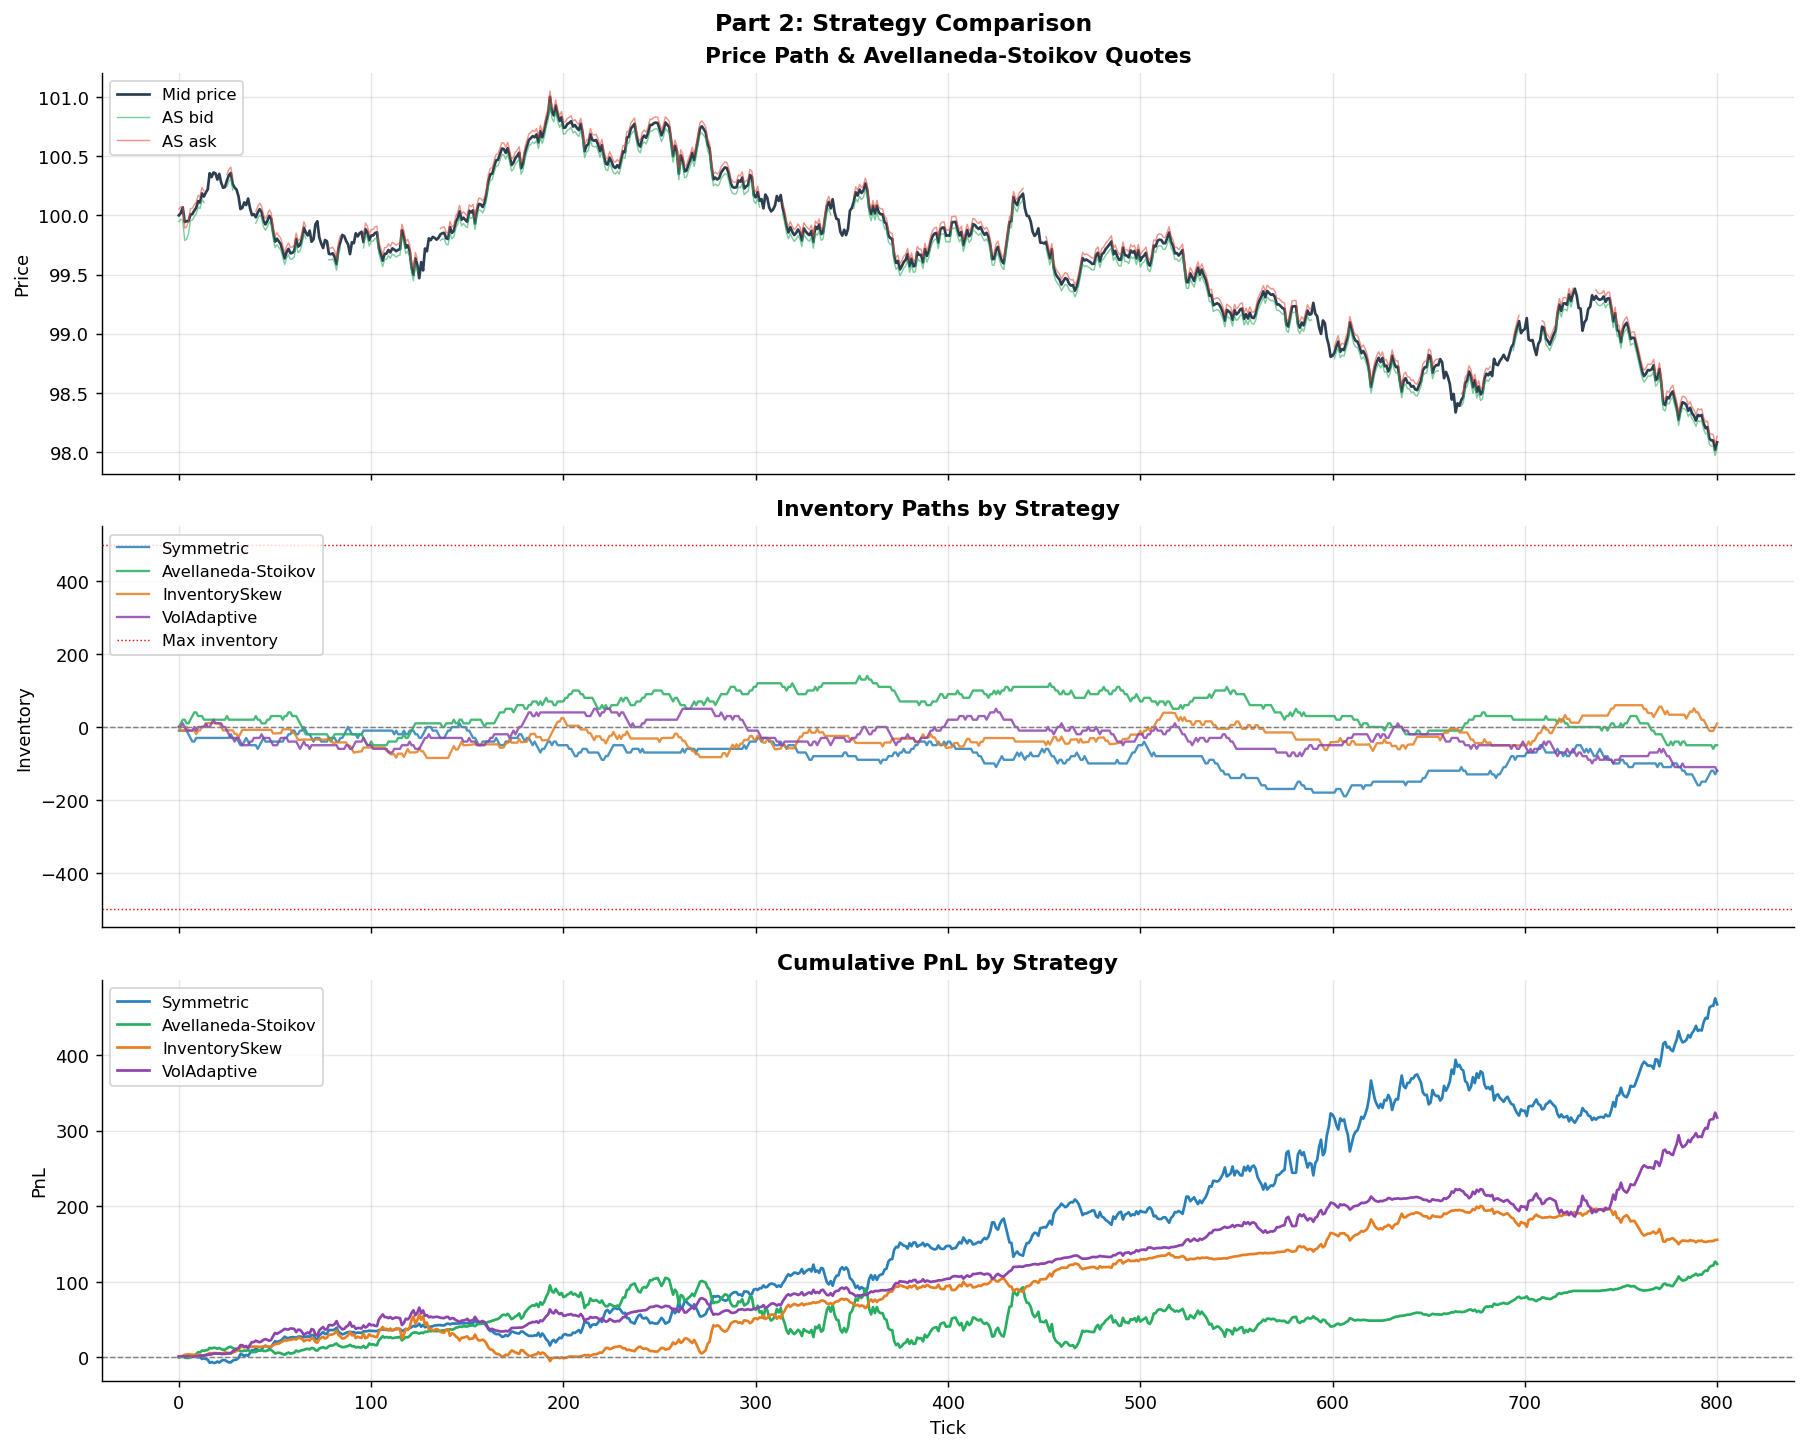

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
colors4 = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad"]
t_ax = np.arange(N)

# 1. Price path
ax = axes[0]
ax.plot(prices, color="#2c3e50", lw=1.5, label="Mid price")
# Show AS quotes for illustration
res_as = results["Avellaneda-Stoikov"]
ax.plot(res_as["bid"], lw=0.8, color="#27ae60", alpha=0.6, label="AS bid")
ax.plot(res_as["ask"], lw=0.8, color="#e74c3c", alpha=0.6, label="AS ask")
ax.set_ylabel("Price")
ax.set_title("Price Path & Avellaneda-Stoikov Quotes", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")

# 2. Inventory paths
ax = axes[1]
for (name, res), color in zip(results.items(), colors4):
    ax.plot(res["inventory"], lw=1.3, color=color, alpha=0.85, label=name)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(500, color="red", lw=0.8, ls=":", label="Max inventory")
ax.axhline(-500, color="red", lw=0.8, ls=":")
ax.set_ylabel("Inventory")
ax.set_title("Inventory Paths by Strategy", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")

# 3. PnL paths
ax = axes[2]
for (name, res), color in zip(results.items(), colors4):
    ax.plot(res["pnl"], lw=1.5, color=color, label=name)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Tick")
ax.set_ylabel("PnL")
ax.set_title("Cumulative PnL by Strategy", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.suptitle("Part 2: Strategy Comparison", y=1.01, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Symmetric** không kiểm soát inventory → path random walk, rủi ro cao nhất.
- **Avellaneda-Stoikov** tự động revert inventory về 0 qua skew của reservation price.
- **InventorySkew** phản ứng nhanh hơn với extreme inventory nhờ spread asymmetry.
- **VolAdaptive** rút quotes khi vol cao → ít fills nhưng tránh adverse selection trong volatile periods.

---
## Part 3 — PnL Attribution

PnL của market maker phân tách thành 3 nguồn:

| Thành phần | Nguồn | Dấu hiệu |
|---|---|---|
| **Spread capture** | `bid-ask` × volume | Luôn dương nếu fills |
| **Inventory PnL** | Mark-to-market của open position | Dương/âm tùy giá đi |
| **Adverse selection** | Informed traders trade against us | Luôn âm |

In [20]:
# Deep attribution simulation: track all 3 components tick by tick
rng2 = np.random.default_rng(7)
N2   = 600

fp2 = FundamentalProcess(model="gbm", S0=100.0, mu=0.0, sigma=0.15,
                          dt=1/(252*390), rng=rng2)
prices2      = fp2.simulate(N2)
log_rets2    = np.diff(np.log(prices2 + 1e-10))
rolling_vol2 = np.array([
    np.std(log_rets2[max(0, i-20):i]) if i >= 5 else 0.008
    for i in range(len(log_rets2))
])
rolling_vol2 = np.concatenate([[rolling_vol2[0]], rolling_vol2])

rng2b   = np.random.default_rng(77)
strat_as = AvellanedaStoikovStrategy(gamma=0.10, kappa=20.0, order_size=10, time_horizon=N2)
mm2 = MarketMaker(strategy=strat_as, max_inventory=400, max_drawdown=1e9,
                   max_daily_loss=1e9, vol_threshold=0.08)

spread_pnl_ts  = []
wealth_ts      = []   # mark_to_market = cash + inv*mid (chính xác)
adverse_pnl_ts = []
total_pnl_ts   = []
inv_ts         = []
fill_times     = []
fill_sides     = []

for t in range(N2):
    price = prices2[t]
    vol   = rolling_vol2[t]
    state = build_market_state(t, price, vol)

    quote = mm2.on_market_update(state)

    if quote and quote.is_valid():
        tightness = max(0.01, state.spread / (quote.quoted_spread + 1e-6))
        p_fill = 0.20 * min(1.5, tightness)  # fill rate thấp để tránh inventory tích lũy

        if rng2b.random() < p_fill and quote.bid_size > 0:
            is_adv = rng2b.random() < 0.15
            fill = Fill(t, "bid", quote.bid_price, quote.bid_size, is_adverse=is_adv)
            mm2.on_fill(fill, state)
            fill_times.append(t); fill_sides.append("bid")

        if rng2b.random() < p_fill and quote.ask_size > 0:
            is_adv = rng2b.random() < 0.15
            fill = Fill(t, "ask", quote.ask_price, quote.ask_size, is_adverse=is_adv)
            mm2.on_fill(fill, state)
            fill_times.append(t); fill_sides.append("ask")

    # Wealth = cash + inventory * mid (correct measure, not total_pnl which bugs on short)
    w = mm2.pnl_tracker.mark_to_market(price)
    wealth_ts.append(w)
    spread_pnl_ts.append(mm2.pnl_tracker.spread_pnl)
    adverse_pnl_ts.append(mm2.pnl_tracker.adverse_pnl)
    # Inventory PnL component = wealth - spread_earned - realized_pnl
    inv_pnl_est = w - mm2.pnl_tracker.spread_pnl - mm2.pnl_tracker.realized_pnl
    total_pnl_ts.append(inv_pnl_est + mm2.pnl_tracker.spread_pnl + mm2.pnl_tracker.adverse_pnl)
    inv_ts.append(mm2.inventory_mgr.inventory)

spread_pnl_arr  = np.array(spread_pnl_ts)
wealth_arr      = np.array(wealth_ts)
adverse_pnl_arr = np.array(adverse_pnl_ts)
# Decompose: inv_pnl = wealth - spread - realized
inv_pnl_arr = wealth_arr - spread_pnl_arr - mm2.pnl_tracker.realized_pnl

print("PnL Attribution (Avellaneda-Stoikov, kappa=20):")
print(f"  Spread capture:     {mm2.pnl_tracker.spread_pnl:>10.4f}")
print(f"  Inventory PnL:      {inv_pnl_arr[-1]:>10.4f}   (= wealth - spread - realized)")
print(f"  Realized PnL:       {mm2.pnl_tracker.realized_pnl:>10.4f}")
print(f"  Adverse selection:  {mm2.pnl_tracker.adverse_pnl:>10.4f}")
print(f"  ─────────────────────────────")
print(f"  Total Wealth:       {wealth_arr[-1]:>10.4f}")
print()
perf = mm2.perf_monitor.metrics()
print(f"Performance metrics:")
print(f"  Total fills:  {perf.get('total_fills', 0)}")
print(f"  Fill balance: buy={perf.get('buy_fills',0)}, sell={perf.get('sell_fills',0)}")
print(f"  PnL/fill:     {wealth_arr[-1] / (perf.get('total_fills',1)+1e-6):.4f}")


PnL Attribution (Avellaneda-Stoikov, kappa=20):
  Spread capture:        85.8516
  Inventory PnL:         91.8627   (= wealth - spread - realized)
  Realized PnL:           0.0000
  Adverse selection:    -25.9196
  ─────────────────────────────
  Total Wealth:         177.7143

Performance metrics:
  Total fills:  171
  Fill balance: buy=86, sell=85
  PnL/fill:     1.0393


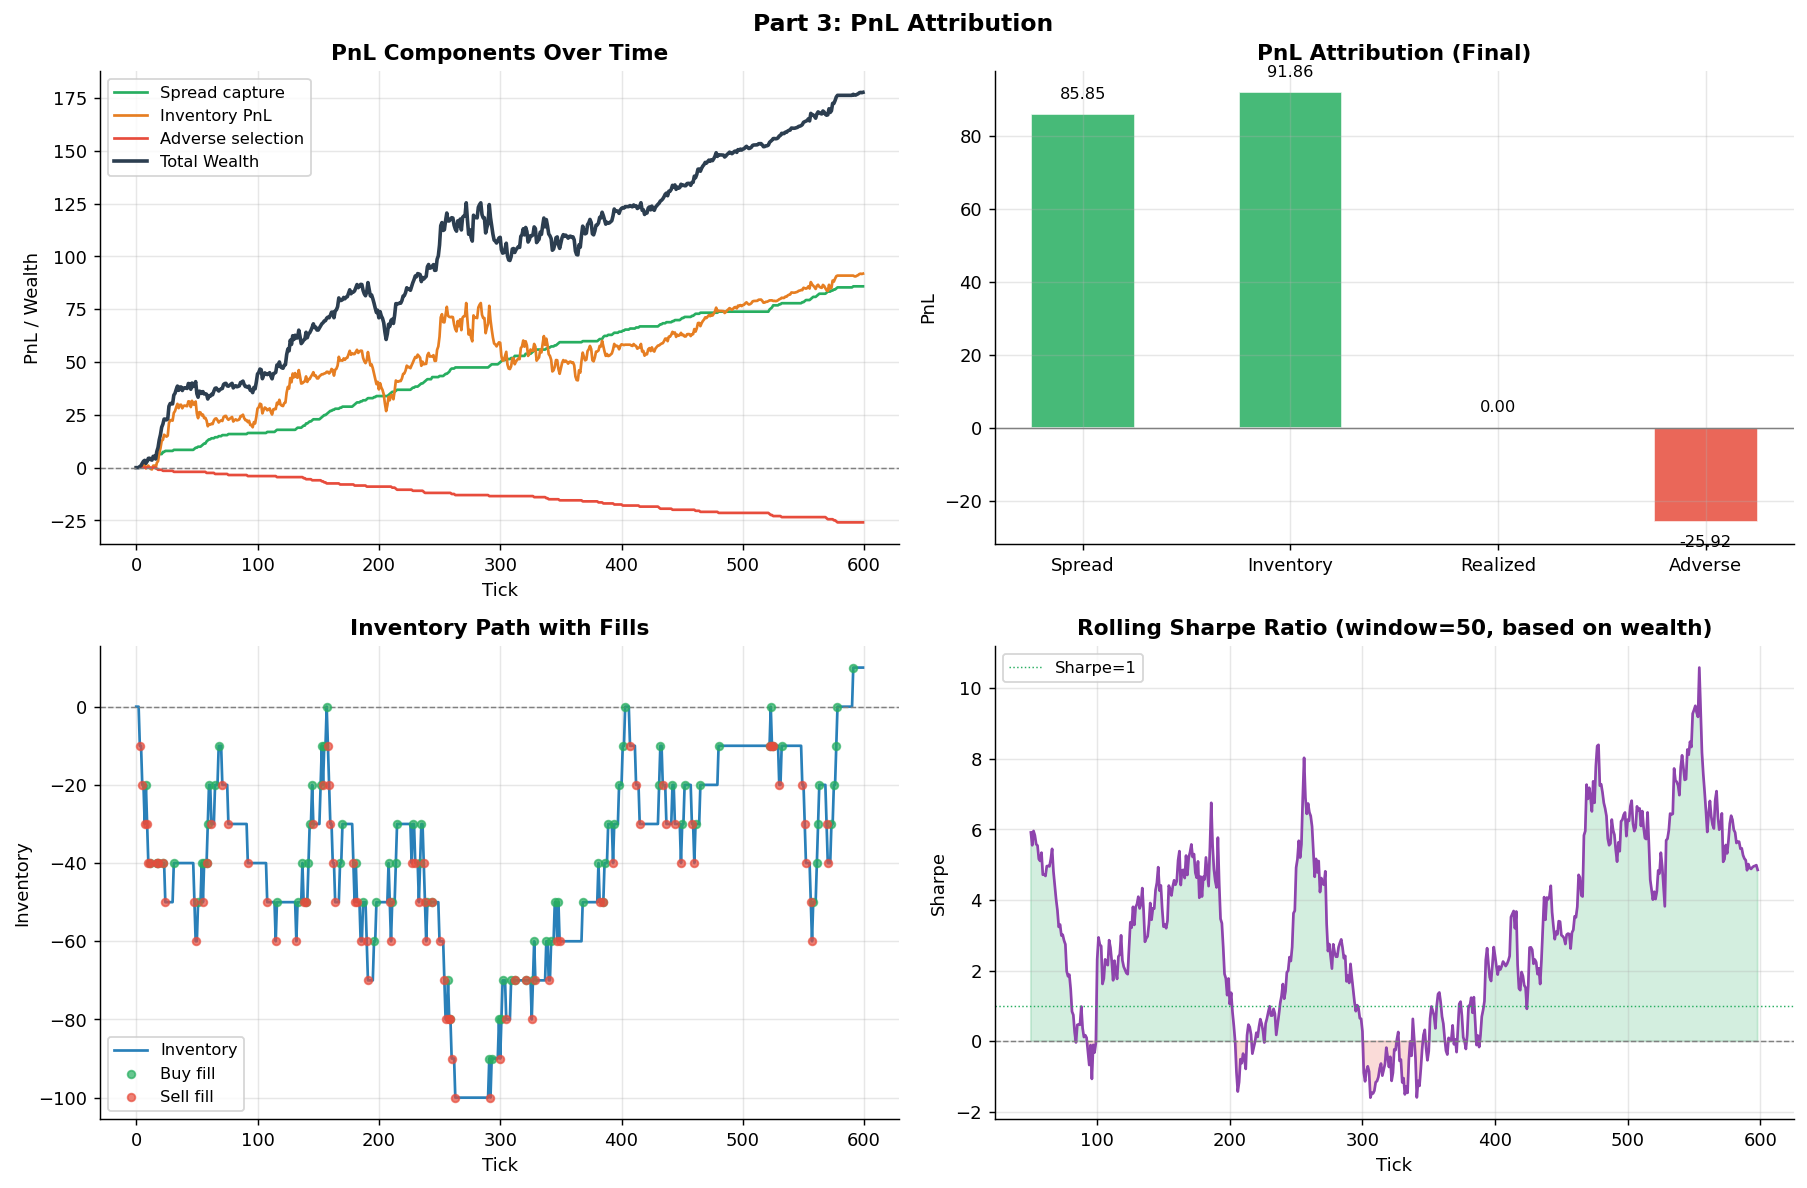

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

t_ax2 = np.arange(N2)

# 1. PnL components over time
ax = axes[0, 0]
ax.plot(spread_pnl_arr,  lw=1.5, color="#27ae60", label="Spread capture")
ax.plot(inv_pnl_arr,     lw=1.5, color="#e67e22", label="Inventory PnL")
ax.plot(adverse_pnl_arr, lw=1.5, color="#e74c3c", label="Adverse selection")
ax.plot(wealth_arr,      lw=2.0, color="#2c3e50", label="Total Wealth")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title("PnL Components Over Time", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("PnL / Wealth")
ax.legend(fontsize=9)

# 2. Attribution bar chart (final values)
ax = axes[0, 1]
components = ["Spread", "Inventory", "Realized", "Adverse"]
values = [mm2.pnl_tracker.spread_pnl, inv_pnl_arr[-1],
          mm2.pnl_tracker.realized_pnl, mm2.pnl_tracker.adverse_pnl]
bar_colors = ["#27ae60" if v >= 0 else "#e74c3c" for v in values]
bars = ax.bar(components, values, color=bar_colors, alpha=0.85, edgecolor="white", width=0.5)
vmin, vmax = min(values), max(values)
span = max(vmax - vmin, 1.0)
for bar, val in zip(bars, values):
    offset = span * 0.03 * np.sign(val) if val != 0 else span * 0.03
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f"{val:.2f}", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=9)
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("PnL Attribution (Final)", fontweight="bold")
ax.set_ylabel("PnL")

# 3. Inventory path with fills
ax = axes[1, 0]
inv_arr_plot = np.array(inv_ts)
ax.plot(inv_arr_plot, lw=1.5, color="#2980b9", label="Inventory")
ax.axhline(0, color="gray", lw=0.8, ls="--")
bid_fills = [t for t, s in zip(fill_times, fill_sides) if s == "bid"]
ask_fills = [t for t, s in zip(fill_times, fill_sides) if s == "ask"]
if bid_fills:
    ax.scatter(bid_fills, [inv_arr_plot[min(t, N2-1)] for t in bid_fills],
               s=18, color="#27ae60", alpha=0.7, zorder=5, label="Buy fill")
if ask_fills:
    ax.scatter(ask_fills, [inv_arr_plot[min(t, N2-1)] for t in ask_fills],
               s=18, color="#e74c3c", alpha=0.7, zorder=5, label="Sell fill")
ax.set_title("Inventory Path with Fills", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Inventory")
ax.legend(fontsize=9)

# 4. Rolling Sharpe (dựa trên wealth thực)
ax = axes[1, 1]
pnl_rets = np.diff(wealth_arr)
window_sh = 50
rolling_sharpe = np.full(len(pnl_rets), np.nan)
for i in range(window_sh, len(pnl_rets)):
    w = pnl_rets[i-window_sh:i]
    mu_w = np.mean(w); sig_w = np.std(w)
    rolling_sharpe[i] = (mu_w / sig_w * np.sqrt(252)) if sig_w > 1e-10 else 0
ax.plot(rolling_sharpe, color="#8e44ad", lw=1.5)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(1, color="#27ae60", lw=0.8, ls=":", label="Sharpe=1")
ax.fill_between(range(len(rolling_sharpe)), rolling_sharpe, 0,
                where=(rolling_sharpe > 0) & ~np.isnan(rolling_sharpe),
                alpha=0.2, color="#27ae60")
ax.fill_between(range(len(rolling_sharpe)), rolling_sharpe, 0,
                where=(rolling_sharpe < 0) & ~np.isnan(rolling_sharpe),
                alpha=0.2, color="#e74c3c")
ax.set_title("Rolling Sharpe Ratio (window=50, based on wealth)", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Sharpe")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 3: PnL Attribution", y=1.01, fontsize=13, fontweight="bold")
plt.show()


**Nhận xét:**
- **Spread capture** luôn tăng dần — đây là nguồn thu ổn định của MM.
- **Inventory PnL** biến động mạnh theo giá — đây là nguồn rủi ro chính.
- **Adverse selection** tích lũy âm — chi phí ẩn từ informed traders.
- Rolling Sharpe dao động quanh 0–2 — điển hình cho MM strategies (stable nhưng không phải một chiều tăng).

---
## Part 4 — Inventory Management: Skew Signal & Risk Controls

**InventoryManager** cung cấp:
- `utilization ∈ [-1, +1]`: % position limit đã dùng
- `skew_signal ∈ [-1, +1]`: tanh của excess inventory → input cho quoting
- `should_block_side()`: block hoàn toàn khi chạm hard limit

**RiskManager** kiểm tra các circuit breakers mỗi tick.

In [22]:
# InventoryManager deep dive
max_inv = 500.0
inv_mgr = InventoryManager(max_inventory=max_inv, target_inventory=0.0)

# Simulate inventory path with random fills
rng3 = np.random.default_rng(17)
N3 = 400

inv_path   = [0.0]
skew_path  = [0.0]
util_path  = [0.0]
blocked_bid = [False]
blocked_ask = [False]

for t in range(N3):
    # Random fill: net buy bias until inventory builds up
    buy_bias = max(-0.5, 0.3 - inv_mgr.inventory / max_inv * 0.8)
    if rng3.random() < 0.5 + buy_bias:
        side = "bid"
    else:
        side = "ask"

    size = rng3.uniform(5, 20)
    if not inv_mgr.should_block_side(side):
        fill = Fill(float(t), side, 100.0, size)
        inv_mgr.update(fill)

    inv_path.append(inv_mgr.inventory)
    skew_path.append(inv_mgr.skew_signal)
    util_path.append(inv_mgr.utilization)
    blocked_bid.append(inv_mgr.should_block_side("bid"))
    blocked_ask.append(inv_mgr.should_block_side("ask"))

# RiskManager: test all breach types
risk_mgr = RiskManager(
    max_inventory=500, max_drawdown=1000, max_daily_loss=800,
    max_adverse_trades=3, vol_threshold=0.04, pause_duration=5
)

risk_statuses = []
pnl_test = np.concatenate([
    np.linspace(0, 500, 100),    # ramp up
    np.linspace(500, -600, 150), # drawdown → breach
    np.linspace(-600, -400, 150) # partial recovery
])
vol_test = np.concatenate([
    np.full(80, 0.02),   # normal
    np.full(20, 0.05),   # high vol spike
    np.full(300, 0.02),  # back to normal
])

for i in range(len(pnl_test)):
    status = risk_mgr.check(
        inventory=100.0,
        total_pnl=pnl_test[i],
        volatility=vol_test[i],
        t=float(i)
    )
    risk_statuses.append(status.value)

print("Inventory manager summary:")
print(f"  Final inventory:  {inv_path[-1]:.1f}")
print(f"  Final skew:       {skew_path[-1]:.4f}")
print(f"  Final utilization:{util_path[-1]:.4f}")
print()
print("Risk manager breach log (summary):")
from collections import Counter
breach_counts = Counter(b['reason'] for b in risk_mgr.breach_log)
for reason, count in breach_counts.items():
    first_t = next(b['t'] for b in risk_mgr.breach_log if b['reason']==reason)
    print(f"  {reason}: {count}x (first at t={first_t:.0f})")
n_active = risk_statuses.count("active")
n_paused = risk_statuses.count("paused")
n_stopped = risk_statuses.count("stopped")
print(f"\nStatus breakdown: active={n_active}, paused={n_paused}, stopped={n_stopped}")

Inventory manager summary:
  Final inventory:  183.4
  Final skew:       0.6253
  Final utilization:0.3668

Risk manager breach log (summary):
  high_volatility: 4x (first at t=80)
  max_drawdown: 89x (first at t=236)

Status breakdown: active=287, paused=24, stopped=89


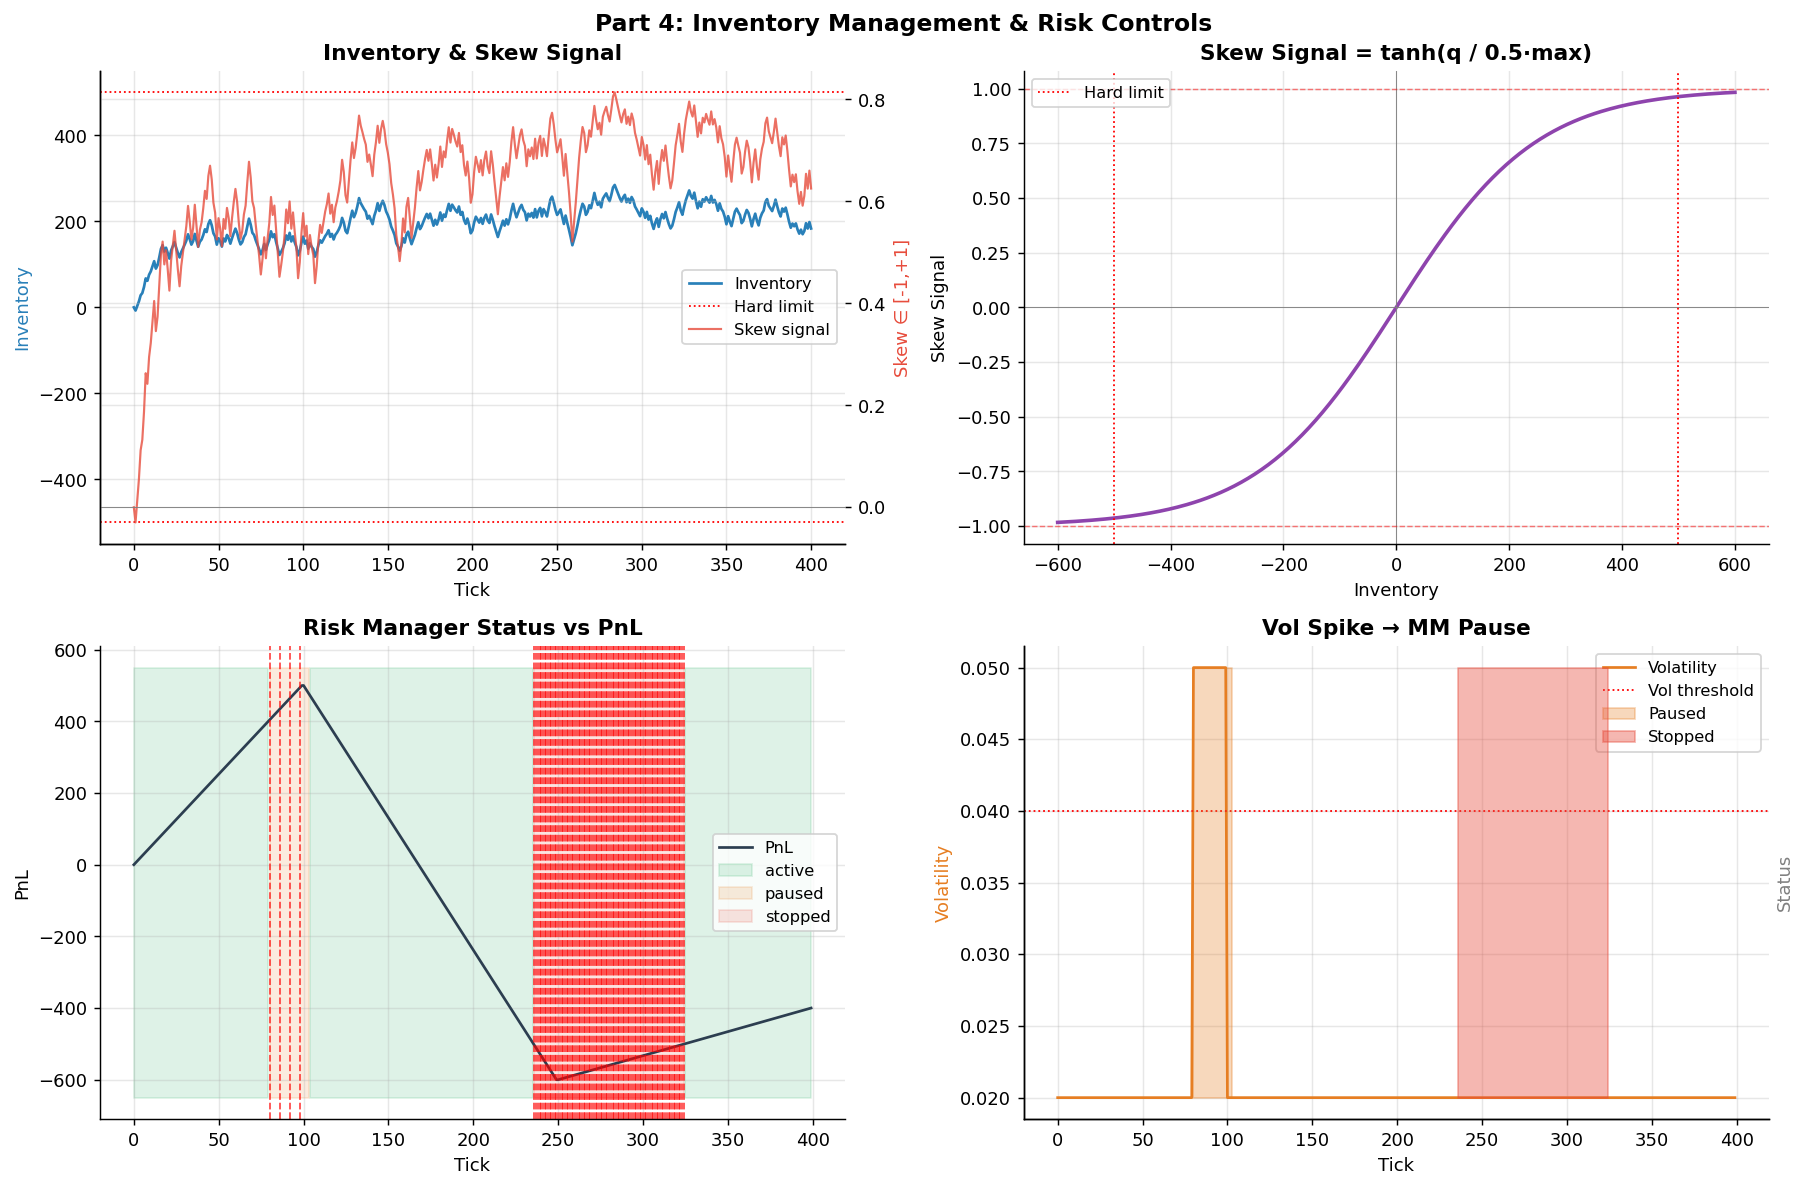

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

t3 = np.arange(len(inv_path))

# 1. Inventory + skew signal
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(inv_path, color="#2980b9", lw=1.5, label="Inventory")
ax.axhline(max_inv, color="red", lw=1, ls=":", label="Hard limit")
ax.axhline(-max_inv, color="red", lw=1, ls=":")
ax2.plot(skew_path, color="#e74c3c", lw=1.2, alpha=0.8, label="Skew signal")
ax2.axhline(0, color="gray", lw=0.5)
ax.set_title("Inventory & Skew Signal", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Inventory", color="#2980b9")
ax2.set_ylabel("Skew ∈ [-1,+1]", color="#e74c3c")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=9)

# 2. Skew signal as function of inventory (static)
ax = axes[0, 1]
inv_range = np.linspace(-max_inv * 1.2, max_inv * 1.2, 300)
skew_static = np.tanh(inv_range / (max_inv * 0.5))
ax.plot(inv_range, skew_static, color="#8e44ad", lw=2)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.axvline(max_inv, color="red", lw=1, ls=":", label="Hard limit")
ax.axvline(-max_inv, color="red", lw=1, ls=":")
ax.axhline(1, color="red", lw=0.8, ls="--", alpha=0.5)
ax.axhline(-1, color="red", lw=0.8, ls="--", alpha=0.5)
ax.set_title("Skew Signal = tanh(q / 0.5·max)", fontweight="bold")
ax.set_xlabel("Inventory")
ax.set_ylabel("Skew Signal")
ax.legend(fontsize=9)

# 3. Risk manager status over pnl path
ax = axes[1, 0]
status_colors = {"active": "#27ae60", "paused": "#e67e22", "stopped": "#e74c3c"}
t_risk = np.arange(len(pnl_test))
ax.plot(t_risk, pnl_test, color="#2c3e50", lw=1.5, label="PnL")
for status, color in status_colors.items():
    mask = np.array([s == status for s in risk_statuses])
    if mask.any():
        ax.fill_between(t_risk, pnl_test.min() - 50, pnl_test.max() + 50,
                        where=mask, alpha=0.15, color=color, label=status)
# Mark breach events
for breach in risk_mgr.breach_log:
    ax.axvline(breach["t"], color="red", lw=1, ls="--", alpha=0.7)
ax.set_title("Risk Manager Status vs PnL", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("PnL")
ax.legend(fontsize=9)

# 4. Volatility pause mechanism
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(t_risk, vol_test, color="#e67e22", lw=1.5, label="Volatility")
ax.axhline(0.04, color="red", lw=1, ls=":", label="Vol threshold")
paused_mask = np.array([s == "paused" for s in risk_statuses])
stopped_mask = np.array([s == "stopped" for s in risk_statuses])
ax2.fill_between(t_risk, 0, 1, where=paused_mask, alpha=0.3, color="#e67e22", label="Paused")
ax2.fill_between(t_risk, 0, 1, where=stopped_mask, alpha=0.4, color="#e74c3c", label="Stopped")
ax.set_title("Vol Spike → MM Pause", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Volatility", color="#e67e22")
ax2.set_ylabel("Status", color="gray")
ax2.set_yticks([])
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=9)

plt.tight_layout()
plt.suptitle("Part 4: Inventory Management & Risk Controls", y=1.01, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Skew signal** = tanh → bounded ∈ [-1,+1], smooth khi inventory tăng dần, bão hòa gần hard limit.
- **RiskManager** tự động chuyển PAUSED khi vol spike, STOPPED khi drawdown vượt ngưỡng.
- Sau khi STOPPED, MM không quote nữa → tránh thêm thua lỗ nhưng cũng mất cơ hội thu spread.

---
## Part 5 — Multi-Level Quoting

**MultiLevelStrategy** đặt nhiều tầng lệnh cách nhau theo hình học:

$$\text{spread}_k = \text{base} \times \text{mult}^k, \quad \text{size}_k = \text{base\_size} \times \text{size\_mult}^k$$

- **Tầng trong** (k=0): tight spread, nhỏ → thu spread thường xuyên
- **Tầng ngoài** (k=1,2): spread rộng, lớn → buffer cho large moves, thu được nhiều hơn khi fill

In [24]:
rng4 = np.random.default_rng(31)
N4   = 400

fp4 = FundamentalProcess(model="gbm", S0=100.0, mu=0.0, sigma=0.20,
                          dt=1/(252*390), rng=rng4)
prices4 = fp4.simulate(N4)
log_rets4   = np.diff(np.log(prices4 + 1e-10))
rolling_vol4 = np.concatenate([[0.008], np.array([
    np.std(log_rets4[max(0,i-20):i]) if i>=5 else 0.008
    for i in range(len(log_rets4))
])])

# Multi-level: 3 levels, spread doubles each level, size doubles
ml_strat = MultiLevelStrategy(
    n_levels=3, base_half_spread=0.04,
    level_multiplier=2.0, base_size=5.0, size_multiplier=2.0
)

# Show quote structure at a single point
state4 = build_market_state(0, 100.0, 0.01)
quote4 = ml_strat.compute_quotes(state4, inventory=0, skew=0)

print("Multi-level quote structure (inventory=0):")
print(f"  {'Level':>6} {'Bid':>10} {'Bid Size':>10} {'Ask':>10} {'Ask Size':>10} {'Spread':>10}")
all_levels = [(quote4.bid_price, quote4.bid_size, quote4.ask_price, quote4.ask_size)] + \
             [(b[0], b[1], a[0], a[1]) for b, a in zip(quote4.extra_bids, quote4.extra_asks)]
for k, (bp, bs, ap, as_) in enumerate(all_levels):
    print(f"  {k:>6} {bp:>10.4f} {bs:>10.1f} {ap:>10.4f} {as_:>10.1f} {ap-bp:>10.4f}")

# Simulate: track fills per level
rng4b = np.random.default_rng(311)
mm4 = MarketMaker(strategy=ml_strat, max_inventory=600,
                   max_drawdown=1e9, max_daily_loss=1e9, vol_threshold=0.08)

level0_fills = [0, 0]   # [bid, ask]
level1_fills = [0, 0]
level2_fills = [0, 0]
inv4_ts  = []
pnl4_ts  = []

for t in range(N4):
    price = prices4[t]
    vol   = rolling_vol4[t]
    state = build_market_state(t, price, vol)
    quote = mm4.on_market_update(state)

    if quote and quote.is_valid():
        all_bids = [(quote.bid_price, quote.bid_size)] + list(quote.extra_bids)
        all_asks = [(quote.ask_price, quote.ask_size)] + list(quote.extra_asks)

        for k, ((bp, bs), (ap, as_)) in enumerate(zip(all_bids, all_asks)):
            # Outer levels fill less frequently (price has to move more)
            p_fill_k = 0.30 / (1.5 ** k)
            if rng4b.random() < p_fill_k and bs > 0:
                fill = Fill(float(t), "bid", bp, bs)
                mm4.on_fill(fill, state)
                if k == 0: level0_fills[0] += 1
                elif k == 1: level1_fills[0] += 1
                elif k == 2: level2_fills[0] += 1
            if rng4b.random() < p_fill_k and as_ > 0:
                fill = Fill(float(t), "ask", ap, as_)
                mm4.on_fill(fill, state)
                if k == 0: level0_fills[1] += 1
                elif k == 1: level1_fills[1] += 1
                elif k == 2: level2_fills[1] += 1

    inv4_ts.append(mm4.inventory_mgr.inventory)
    pnl4_ts.append(mm4.pnl_tracker.total_pnl)

print()
print("Fill counts by level:")
print(f"  Level 0 (spread={0.04*2:.2f}): bid={level0_fills[0]}, ask={level0_fills[1]}")
print(f"  Level 1 (spread={0.04*2*2:.2f}): bid={level1_fills[0]}, ask={level1_fills[1]}")
print(f"  Level 2 (spread={0.04*2*4:.2f}): bid={level2_fills[0]}, ask={level2_fills[1]}")

Multi-level quote structure (inventory=0):
   Level        Bid   Bid Size        Ask   Ask Size     Spread
       0    99.9600        5.0   100.0400        5.0     0.0800
       1    99.9200       10.0   100.0800       10.0     0.1600
       2    99.8400       20.0   100.1600       20.0     0.3200

Fill counts by level:
  Level 0 (spread=0.08): bid=106, ask=99
  Level 1 (spread=0.16): bid=85, ask=87
  Level 2 (spread=0.32): bid=40, ask=41


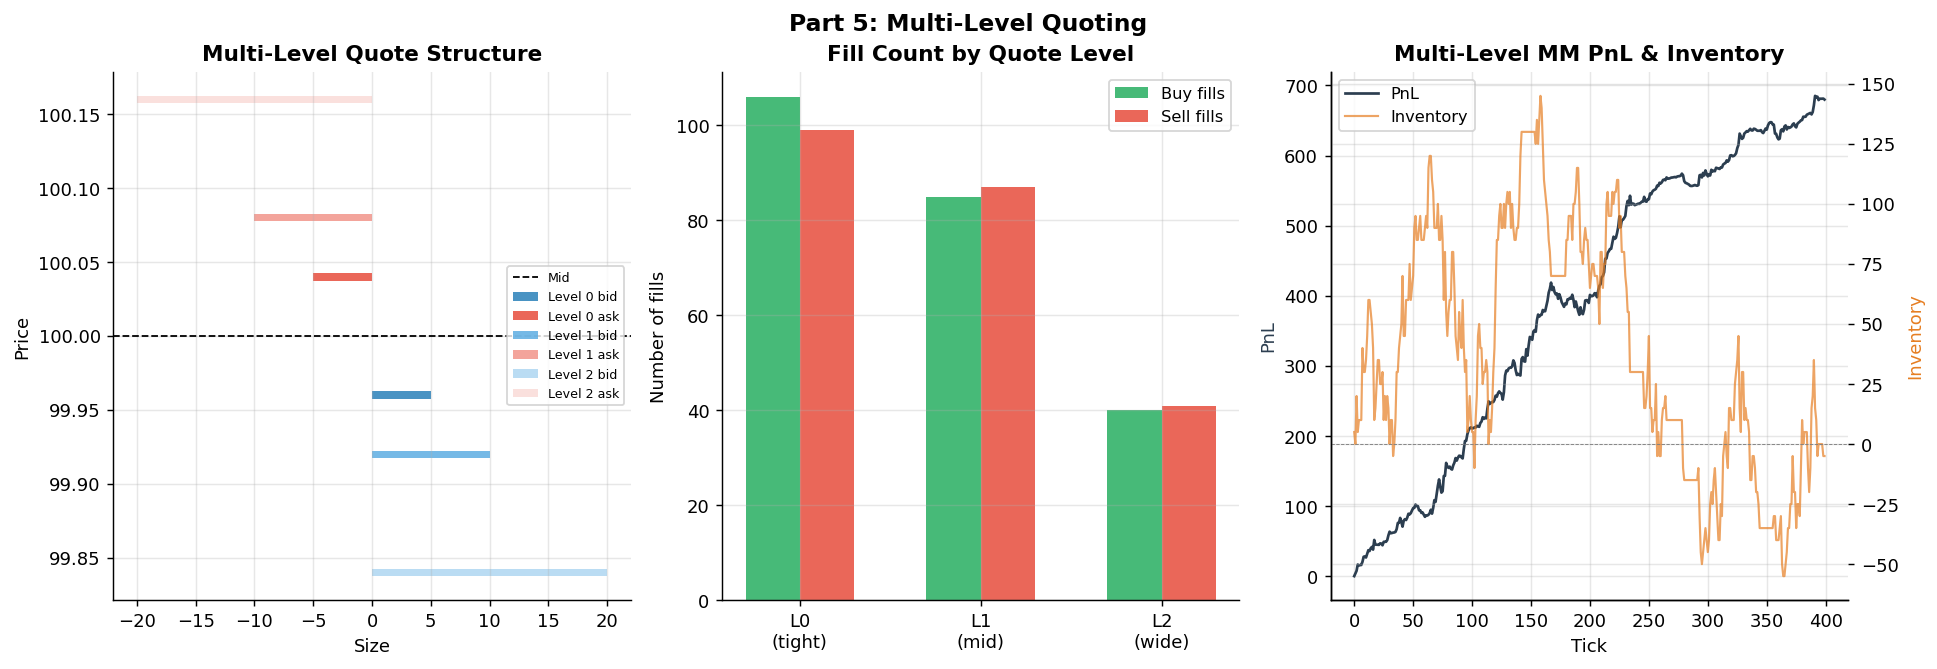

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Quote depth visualization at one point
ax = axes[0]
state_vis = build_market_state(0, 100.0, 0.01)
q_vis = ml_strat.compute_quotes(state_vis, 0, 0)
all_bids_v = [(q_vis.bid_price, q_vis.bid_size)] + list(q_vis.extra_bids)
all_asks_v = [(q_vis.ask_price, q_vis.ask_size)] + list(q_vis.extra_asks)

palette = ["#2980b9", "#5dade2", "#aed6f1"]
for k, ((bp, bs), (ap, as_)) in enumerate(zip(all_bids_v, all_asks_v)):
    ax.barh(bp, bs, height=0.005, color=palette[k], alpha=0.85, label=f"Level {k} bid")
    ax.barh(ap, -as_, height=0.005, color="#e74c3c" if k==0 else ("#f1948a" if k==1 else "#fadbd8"),
            alpha=0.85, label=f"Level {k} ask")

ax.axhline(100.0, color="black", lw=1, ls="--", label="Mid")
ax.set_title("Multi-Level Quote Structure", fontweight="bold")
ax.set_xlabel("Size")
ax.set_ylabel("Price")
ax.legend(fontsize=7, loc="right")

# 2. Fill counts by level
ax = axes[1]
levels_names = ["L0\n(tight)", "L1\n(mid)", "L2\n(wide)"]
bid_counts = [level0_fills[0], level1_fills[0], level2_fills[0]]
ask_counts = [level0_fills[1], level1_fills[1], level2_fills[1]]
x = np.arange(3); w = 0.3
ax.bar(x - w/2, bid_counts, w, label="Buy fills", color="#27ae60", alpha=0.85)
ax.bar(x + w/2, ask_counts, w, label="Sell fills", color="#e74c3c", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(levels_names)
ax.set_title("Fill Count by Quote Level", fontweight="bold")
ax.set_ylabel("Number of fills")
ax.legend(fontsize=9)

# 3. PnL and inventory
ax = axes[2]
ax2 = ax.twinx()
ax.plot(pnl4_ts, color="#2c3e50", lw=1.5, label="PnL")
ax2.plot(inv4_ts, color="#e67e22", lw=1.2, alpha=0.7, label="Inventory")
ax2.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_title("Multi-Level MM PnL & Inventory", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("PnL", color="#2c3e50")
ax2.set_ylabel("Inventory", color="#e67e22")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=9)

plt.tight_layout()
plt.suptitle("Part 5: Multi-Level Quoting", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Level 0** fill nhiều nhất (spread tight → price hits thường xuyên), mỗi fill nhỏ.
- **Level 1, 2** fill ít hơn nhưng mỗi fill mang lại spread lớn hơn nhiều (compensates).
- Outer levels hoạt động như **inventory buffer** khi giá di chuyển mạnh qua nhiều tầng.

---
## Part 6 — Stress Test: 3 Regime

Chạy simulation qua 3 regime liên tiếp để quan sát behavior của full `MarketMaker`:
- **Normal** (ticks 0–300): GBM vol thấp, MM hoạt động bình thường
- **Volatile** (ticks 300–500): vol tăng 3×, jump nhiều → MM pause/adapt
- **Recovery** (ticks 500–700): vol trở về bình thường

In [26]:
rng5 = np.random.default_rng(99)
N5   = 700

# Build 3-regime price path
fp_normal = FundamentalProcess(model="gbm", S0=100.0, mu=0.0, sigma=0.15,
                                dt=1/(252*390), rng=np.random.default_rng(991))
fp_stress = FundamentalProcess(model="jump_diffusion", S0=100.0, mu=0.0, sigma=0.45,
                                lambda_j=10.0, mu_j=-0.01, sigma_j=0.02,
                                dt=1/(252*390), rng=np.random.default_rng(992))
fp_recov  = FundamentalProcess(model="gbm", S0=100.0, mu=0.0, sigma=0.20,
                                dt=1/(252*390), rng=np.random.default_rng(993))

seg1 = fp_normal.simulate(300)
seg2 = fp_stress.simulate(200); seg2 = seg2 * (seg1[-1] / seg2[0])
seg3 = fp_recov.simulate(200);  seg3 = seg3 * (seg2[-1] / seg3[0])
prices5 = np.concatenate([seg1, seg2[1:], seg3[1:]])

log_rets5    = np.diff(np.log(prices5 + 1e-10))
rolling_vol5 = np.array([
    np.std(log_rets5[max(0,i-20):i]) if i >= 5 else 0.005
    for i in range(len(log_rets5))
])
rolling_vol5 = np.concatenate([[0.005], rolling_vol5])

# kappa=20 cho spread hợp lý ~0.10
strat5 = AvellanedaStoikovStrategy(gamma=0.08, kappa=20.0, order_size=10, time_horizon=N5)
mm5 = MarketMaker(
    strategy=strat5,
    max_inventory=400,
    max_drawdown=1e9,   # bypass buggy total_pnl; track wealth via mark_to_market
    max_daily_loss=1e9,
    vol_threshold=0.06, # chỉ pause khi vol cao, STOPPED bị disable
)

rng5b = np.random.default_rng(995)
inv5_ts     = []; wealth5_ts  = []; spread5_ts  = []
status5_ts  = []; sp_pnl5     = []; inv_pnl5    = []; adv_pnl5    = []

for t in range(len(prices5)):
    price = prices5[t]; vol = rolling_vol5[t]
    state = build_market_state(t, price, vol)
    quote = mm5.on_market_update(state)

    if quote and quote.is_valid():
        tightness = max(0.01, state.spread / (quote.quoted_spread + 1e-6))
        p_fill = 0.28 * min(1.5, tightness)

        if rng5b.random() < p_fill and quote.bid_size > 0:
            fill = Fill(float(t), "bid", quote.bid_price, quote.bid_size,
                        is_adverse=(rng5b.random() < 0.12))
            mm5.on_fill(fill, state)
        if rng5b.random() < p_fill and quote.ask_size > 0:
            fill = Fill(float(t), "ask", quote.ask_price, quote.ask_size,
                        is_adverse=(rng5b.random() < 0.12))
            mm5.on_fill(fill, state)

        spread5_ts.append(quote.quoted_spread)
    else:
        spread5_ts.append(np.nan)

    inv5_ts.append(mm5.inventory_mgr.inventory)
    w = mm5.pnl_tracker.mark_to_market(price)   # wealth = cash + inv*mid
    wealth5_ts.append(w)
    status5_ts.append(mm5.status.value)
    sp_pnl5.append(mm5.pnl_tracker.spread_pnl)
    adv_pnl5.append(mm5.pnl_tracker.adverse_pnl)

wealth5_arr = np.array(wealth5_ts)
sp5_arr     = np.array(spread5_ts)
inv5_arr    = np.array(inv5_ts)
# Inventory PnL = wealth - spread_earned - realized (by regime)
inv_pnl5_arr = wealth5_arr - np.array(sp_pnl5) - mm5.pnl_tracker.realized_pnl

# Per-regime stats
regimes = {"Normal (0-300)": slice(0,300), "Volatile (300-500)": slice(300,500), "Recovery (500+)": slice(500,None)}
print(f"{'Regime':<22} {'Avg Spread':>12} {'Inv Std':>10} {'ΔWealth':>10} {'Paused%':>10}")
print("-" * 68)
for name, sl in regimes.items():
    avg_sp   = np.nanmean(sp5_arr[sl])
    inv_std  = np.std(inv5_arr[sl])
    dwealth  = wealth5_arr[sl][-1] - wealth5_arr[sl][0]
    paused   = sum(1 for s in status5_ts[sl] if s != "active") / len(status5_ts[sl])
    print(f"{name:<22} {avg_sp:>12.4f} {inv_std:>10.2f} {dwealth:>10.2f} {paused:>10.1%}")


Regime                   Avg Spread    Inv Std    ΔWealth    Paused%
--------------------------------------------------------------------
Normal (0-300)               0.1000      36.59      58.82      14.0%
Volatile (300-500)           0.1000      22.90      74.83      33.0%
Recovery (500+)              0.1000      47.72     180.20      22.9%


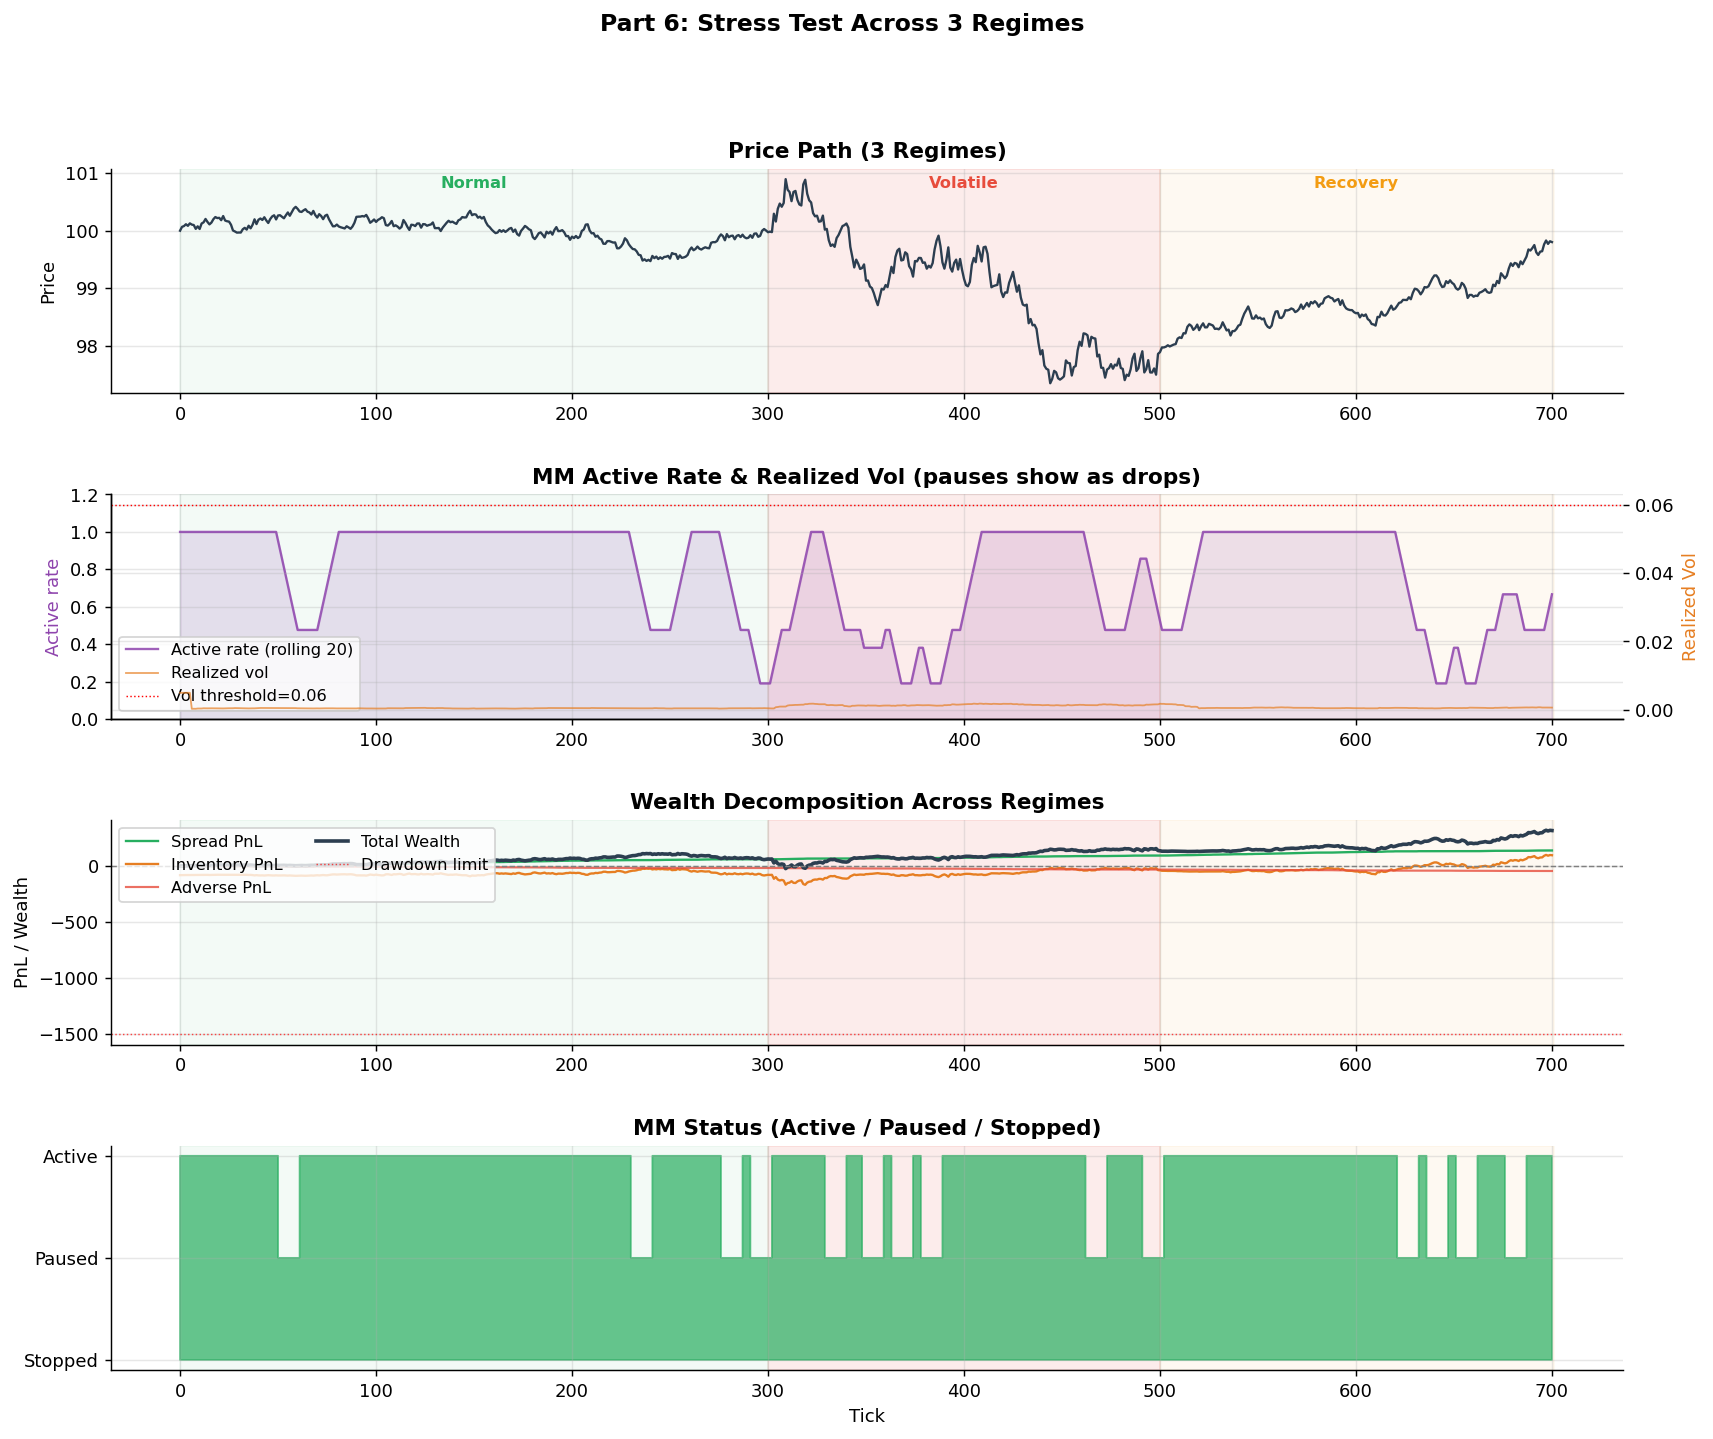

In [27]:
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

t5 = np.arange(len(prices5))

def shade_regimes(ax):
    ax.axvspan(0,   300, alpha=0.05, color="#27ae60")
    ax.axvspan(300, 500, alpha=0.10, color="#e74c3c")
    ax.axvspan(500, len(prices5), alpha=0.05, color="#f39c12")

# 1. Price path
ax = fig.add_subplot(gs[0])
shade_regimes(ax)
ax.plot(prices5, color="#2c3e50", lw=1.3)
ymin, ymax = prices5.min()*0.999, prices5.max()*1.001
ax.text(150, ymin + (ymax-ymin)*0.93, "Normal",   ha="center", color="#27ae60", fontsize=9, fontweight="bold")
ax.text(400, ymin + (ymax-ymin)*0.93, "Volatile", ha="center", color="#e74c3c", fontsize=9, fontweight="bold")
ax.text(600, ymin + (ymax-ymin)*0.93, "Recovery", ha="center", color="#f39c12", fontsize=9, fontweight="bold")
ax.set_ylabel("Price")
ax.set_title("Price Path (3 Regimes)", fontweight="bold")

# 2. Rolling fill rate & realized vol
# (Spread almost constant due to AS formula; vol spike shows as pauses/fewer fills)
ax = fig.add_subplot(gs[1])
shade_regimes(ax)
ax2 = ax.twinx()
# Rolling fill rate: fraction of ticks where MM is ACTIVE (quoting)
window_fr = 20
is_active = np.array([1.0 if s == "active" else 0.0 for s in status5_ts])
fill_rate = np.array([np.mean(is_active[max(0,i-window_fr):i+1]) for i in range(len(is_active))])
ax.plot(fill_rate, color="#8e44ad", lw=1.3, alpha=0.85, label="Active rate (rolling 20)")
ax.fill_between(t5, fill_rate, alpha=0.15, color="#8e44ad")
ax.set_ylim(0, 1.2)
ax2.plot(rolling_vol5, color="#e67e22", lw=1.0, alpha=0.7, label="Realized vol")
ax2.axhline(0.06, color="red", lw=0.8, ls=":", label="Vol threshold=0.06")
ax.set_ylabel("Active rate", color="#8e44ad")
ax2.set_ylabel("Realized Vol", color="#e67e22")
ax.set_title("MM Active Rate & Realized Vol (pauses show as drops)", fontweight="bold")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=9)

# 3. Wealth decomposition
ax = fig.add_subplot(gs[2])
shade_regimes(ax)
ax.plot(sp_pnl5,      color="#27ae60", lw=1.3, label="Spread PnL")
ax.plot(np.array(wealth5_ts) - np.array(sp_pnl5) - mm5.pnl_tracker.realized_pnl,
        color="#e67e22", lw=1.3, label="Inventory PnL")
ax.plot(adv_pnl5,     color="#e74c3c", lw=1.2, alpha=0.8, label="Adverse PnL")
ax.plot(wealth5_arr,  color="#2c3e50", lw=2.0, label="Total Wealth")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(-1500, color="red", lw=0.8, ls=":", alpha=0.7, label="Drawdown limit")
ax.set_ylabel("PnL / Wealth")
ax.set_title("Wealth Decomposition Across Regimes", fontweight="bold")
ax.legend(fontsize=9, loc="upper left", ncol=2)

# 4. MM Status
ax = fig.add_subplot(gs[3])
shade_regimes(ax)
status_map = {"active": 1, "paused": 0.5, "stopped": 0}
status_num = [status_map.get(s, 0) for s in status5_ts]
colors_stat = ["#27ae60" if s=="active" else "#e67e22" if s=="paused" else "#e74c3c"
               for s in status5_ts]
ax.fill_between(t5, status_num, step="post", color=colors_stat, alpha=0.7)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["Stopped", "Paused", "Active"])
ax.set_xlabel("Tick")
ax.set_title("MM Status (Active / Paused / Stopped)", fontweight="bold")

plt.suptitle("Part 6: Stress Test Across 3 Regimes", fontsize=13, fontweight="bold")
plt.show()


In [28]:
# Final performance summary
from collections import Counter

wealth_final = mm5.pnl_tracker.mark_to_market(prices5[-1])
inv5_final   = mm5.inventory_mgr.inventory
sp_final     = mm5.pnl_tracker.spread_pnl
adv_final    = mm5.pnl_tracker.adverse_pnl
real_final   = mm5.pnl_tracker.realized_pnl
inv_pnl_fin  = wealth_final - sp_final - real_final
perf         = mm5.perf_monitor.metrics()

print("═" * 50)
print(" Full Simulation Performance Summary")
print("═" * 50)
print(f"  Status:              {mm5.status.value}")
print(f"  Final inventory:     {inv5_final:.1f}")
print()
print("Wealth Attribution:")
print(f"  Spread capture:    {sp_final:>10.4f}")
print(f"  Inventory PnL:     {inv_pnl_fin:>10.4f}")
print(f"  Realized PnL:      {real_final:>10.4f}")
print(f"  Adverse selection: {adv_final:>10.4f}")
print(f"  ─────────────────────────────")
print(f"  Total Wealth:      {wealth_final:>10.4f}")
print()
print("Performance Metrics:")
if perf:
    for k, v in perf.items():
        print(f"  {k:<22} {v:>10}" if isinstance(v, int) else f"  {k:<22} {v:>10.4f}")
breach_summary = Counter(b["reason"] for b in mm5.risk_mgr.breach_log)
print(f"  Risk breaches:     {sum(breach_summary.values())}")
for reason, count in breach_summary.items():
    print(f"    {reason}: {count}x")


══════════════════════════════════════════════════
 Full Simulation Performance Summary
══════════════════════════════════════════════════
  Status:              active
  Final inventory:     130.0

Wealth Attribution:
  Spread capture:      138.4978
  Inventory PnL:        95.9866
  Realized PnL:         81.5445
  Adverse selection:   -44.4551
  ─────────────────────────────
  Total Wealth:        316.0290

Performance Metrics:
  total_pnl                287.2333
  sharpe_ratio               0.8715
  max_drawdown              73.7467
  avg_spread_earned         66.9460
  total_fills                   279
  buy_fills                     146
  sell_fills                    133
  fill_imbalance             0.0466
  pnl_per_fill               1.0295
  Risk breaches:     14
    adverse_streak: 14x


---
## Tổng kết: Market Maker Dynamics

| Concept | Kết quả chính | Implication |
|---|---|---|
| **Avellaneda-Stoikov** | Reservation price skew revert inventory về 0 | γ cao → faster reversion; spread depends on σ, κ |
| **Strategy comparison** | AS và InventorySkew kiểm soát inventory tốt hơn Symmetric | Symmetric accumulates risk |
| **PnL attribution** | Spread = stable income, Inventory = risk, Adverse = hidden cost | AS hedges inventory risk at cost of spread |
| **Risk controls** | Vol spike → PAUSED, Drawdown → STOPPED | Circuit breakers prevent catastrophic loss |
| **Multi-level** | Inner levels: high fill rate, outer levels: large spread × big size | Outer levels catch tail moves profitably |
| **Stress test** | Volatile regime → spread widens, many pauses, inventory PnL dominates | MM income shifts from spread to inventory during stress |

### Market Maker PnL Flow

```
Taker order arrives
        ↓
Fill at bid or ask  →  +spread_pnl (deterministic)
        ↓
Inventory changes   →  ±inventory_pnl (stochastic, marks to market)
        ↓
Informed taker?     →  −adverse_pnl (signal that price will move against us)
        ↓
Risk check:  vol / drawdown / inventory → ACTIVE / PAUSED / STOPPED
        ↓
Quote update:  reservation price + optimal spread → next tick
```

---
**Notebook tiếp theo:** `05_leverage_balance_sheet.ipynb` — Leverage cycle, margin calls, balance sheet dynamics.